# Phase 3: Biologically Inspired Hidden Perturbations

Models are trained from scratch under each perturbation applied to the **1st hidden layer output**.  
Two model variants are compared:
- **SGD-delay** (solid, filled circles): SNN with learnable axonal delays.
- **SGD** (dashed, × markers): baseline SNN without delays.

Three dataset variants: **Whole** (blue), **Part** (green), **Norm** (red).

## 3A-C: Jitter, Shift and Deletion

The three timing perturbations are shown side by side in a single figure:

- **(a) Per-Spike Jitter** — independent Gaussian noise (σ ms) added to each spike time in the hidden layer output. Sweep: σ = 0 → 25 ms.
- **(b) Per-Neuron Shift** — the same Gaussian offset applied to **all spikes from a given hidden neuron**, preserving intra-neuron ISI while disrupting cross-neuron timing. Sweep: σ = 0 → 25 ms.
- **(c) Spike Deletion** — each hidden spike independently dropped with probability $p_d$, reducing total spike count while preserving the timing of survivors. Sweep: $p_d$ = 0.0 → 0.8. These results come from the **eval-only** protocol: for each `(dataset, delay-mode)` the shared clean-trained jitter checkpoint is evaluated across the $p_d$ sweep.

All three panels share the y-axis and the legend.

In [28]:
import json
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "legend.fontsize": 9.5,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "figure.dpi": 150,
})

# Notebook lives in result_visualization/FWP_1stLayer_results/perturbation/;
# sweep results are read in place from exp_fixed_weight_perturbation/code/perturbation/.
CODE_PERTURBATION_DIR = pathlib.Path("../../../code/perturbation")

COLORS = {"Whole": "#1f77b4", "Part": "#2ca02c", "Norm": "#d62728"}


def load_sweep(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Return (sigma_values, means_pct, stds_pct) from a sweep results JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    sigmas = sorted(int(k) for k in raw)
    means = np.array([raw[str(s)]["mean"] for s in sigmas]) * 100
    stds = np.array([raw[str(s)]["std"] for s in sigmas]) * 100
    return sigmas, means, stds

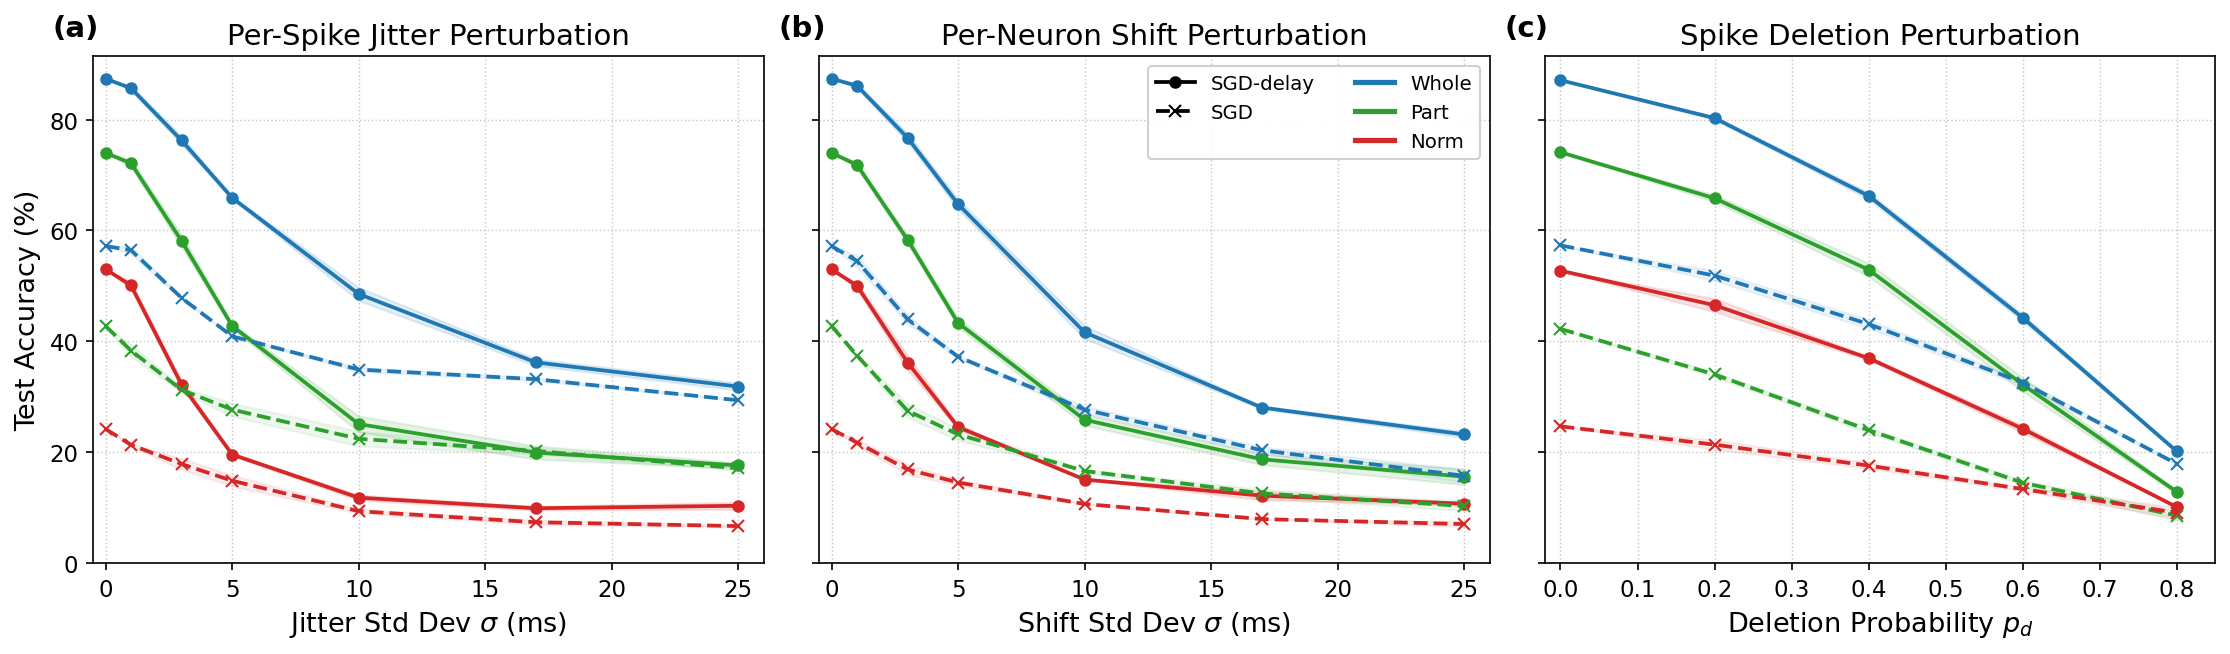

In [29]:
JITTER_LOG = CODE_PERTURBATION_DIR / "jitter/log"
SHIFT_LOG = CODE_PERTURBATION_DIR / "shift/log"
DELETION_LOG = CODE_PERTURBATION_DIR / "deletion/log"

VARIANTS = ("Whole", "Part", "Norm")


def load_sweep_float(path: pathlib.Path) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Like load_sweep but treats result-keys as floats (for p_d / f values)."""
    with open(path) as fh:
        raw = json.load(fh)
    items = sorted(((float(k), k) for k in raw), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([raw[k]["mean"] for _, k in items]) * 100
    stds = np.array([raw[k]["std"] for _, k in items]) * 100
    return xs, means, stds


def load_group(
    log_dir: pathlib.Path,
    filename_template: str,
    loader,
) -> dict[tuple[str, bool], tuple[list, np.ndarray, np.ndarray]]:
    """Load one perturbation's six sweeps, keyed by (dataset_variant, uses_delay).

    Args:
        log_dir: Directory holding the sweep result JSONs.
        filename_template: Template with ``{variant}`` and ``{mode}`` fields.
        loader: Either ``load_sweep`` (integer keys) or ``load_sweep_float``.

    Returns:
        Mapping from (variant, uses_delay) to (x_values, means_pct, stds_pct).
    """
    sweeps = {}
    for variant in VARIANTS:
        for uses_delay in (True, False):
            filename = filename_template.format(
                variant=variant.lower(),
                mode="delay" if uses_delay else "nodelay",
            )
            sweeps[(variant, uses_delay)] = loader(log_dir / filename)
    return sweeps


def draw_sweep_panel(
    ax: plt.Axes,
    sweeps: dict,
    title: str,
    xlabel: str,
    xlim: tuple[float, float],
) -> None:
    """Draw one perturbation sweep panel onto *ax*.

    SGD-delay curves are solid with filled circles, SGD (no delay) curves are
    dashed with x markers; colour encodes the dataset variant.
    """
    for uses_delay, style, markersize, alpha in [
        (True, "o-", 5, 0.12),
        (False, "x--", 6, 0.08),
    ]:
        for variant in VARIANTS:
            xs, means, stds = sweeps[(variant, uses_delay)]
            ax.plot(xs, means, style, color=COLORS[variant],
                    markersize=markersize, linewidth=1.8)
            ax.fill_between(xs, means - stds, means + stds,
                            color=COLORS[variant], alpha=alpha)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_xlim(*xlim)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)


# ---------- Load sweep results ----------
jitter_sweeps = load_group(
    JITTER_LOG, "jitter_{variant}_{mode}_jitter_sweep_results.json", load_sweep)
shift_sweeps = load_group(
    SHIFT_LOG, "shift_{variant}_{mode}_shift_sweep_results.json", load_sweep)
deletion_sweeps = load_group(
    DELETION_LOG, "deletion_{variant}_{mode}_evalOnly_deletion_sweep_results.json",
    load_sweep_float)

# ---------- Plot: jitter | shift | deletion ----------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

panels = [
    (jitter_sweeps, "Per-Spike Jitter Perturbation",
     r"Jitter Std Dev $\sigma$ (ms)", (-0.5, 26)),
    (shift_sweeps, "Per-Neuron Shift Perturbation",
     r"Shift Std Dev $\sigma$ (ms)", (-0.5, 26)),
    (deletion_sweeps, "Spike Deletion Perturbation",
     r"Deletion Probability $p_d$", (-0.02, 0.85)),
]

for ax, panel_label, (sweeps, title, xlabel, xlim) in zip(axes, "abc", panels):
    draw_sweep_panel(ax, sweeps, title, xlabel, xlim)
    ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
            fontsize=14, fontweight="bold")

axes[0].set_ylabel("Test Accuracy (%)")
axes[0].set_ylim(0, None)

# ---------- Shared legend, drawn once in the middle panel ----------
# Matplotlib fills legend columns top-to-bottom, so a blank third entry keeps
# the line styles in column 1 and the dataset variants together in column 2.
blank = mlines.Line2D([], [], linestyle="none", marker="none", label="")
handles = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                  markersize=5, linewidth=1.8, label="SGD-delay"),
    mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                  markersize=6, linewidth=1.8, label="SGD"),
    blank,
] + [
    mlines.Line2D([], [], color=COLORS[variant], linewidth=2.5, label=variant)
    for variant in VARIANTS
]
axes[1].legend(handles=handles, loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("timing_perturbation_results.png", dpi=150, bbox_inches="tight")
plt.show()

# Phase 4: Time Reversal at Hidden Layer

The pre-trained 2-hidden-layer SNN is evaluated under two conditions at
each hidden perturbation level $f$:

- **No reversal** (baseline): a fraction $f$ of each neuron's hidden spikes
  is relocated to random empty time bins, preserving spike count.
- **With reversal**: in addition to the $f$-perturbation, each sample's
  hidden spike trains are time-reversed within the sample-wide active
  window. This preserves spike count, per-neuron rate, intra-neuron ISI,
  and cross-neuron coincidence — only causal temporal order is flipped.

Comparing the two reveals how much downstream layers rely on causal
temporal order in the hidden representation. Sweep: $f$ = 0.0 → 1.0.

## 4A: Hidden-Layer Time Reversal

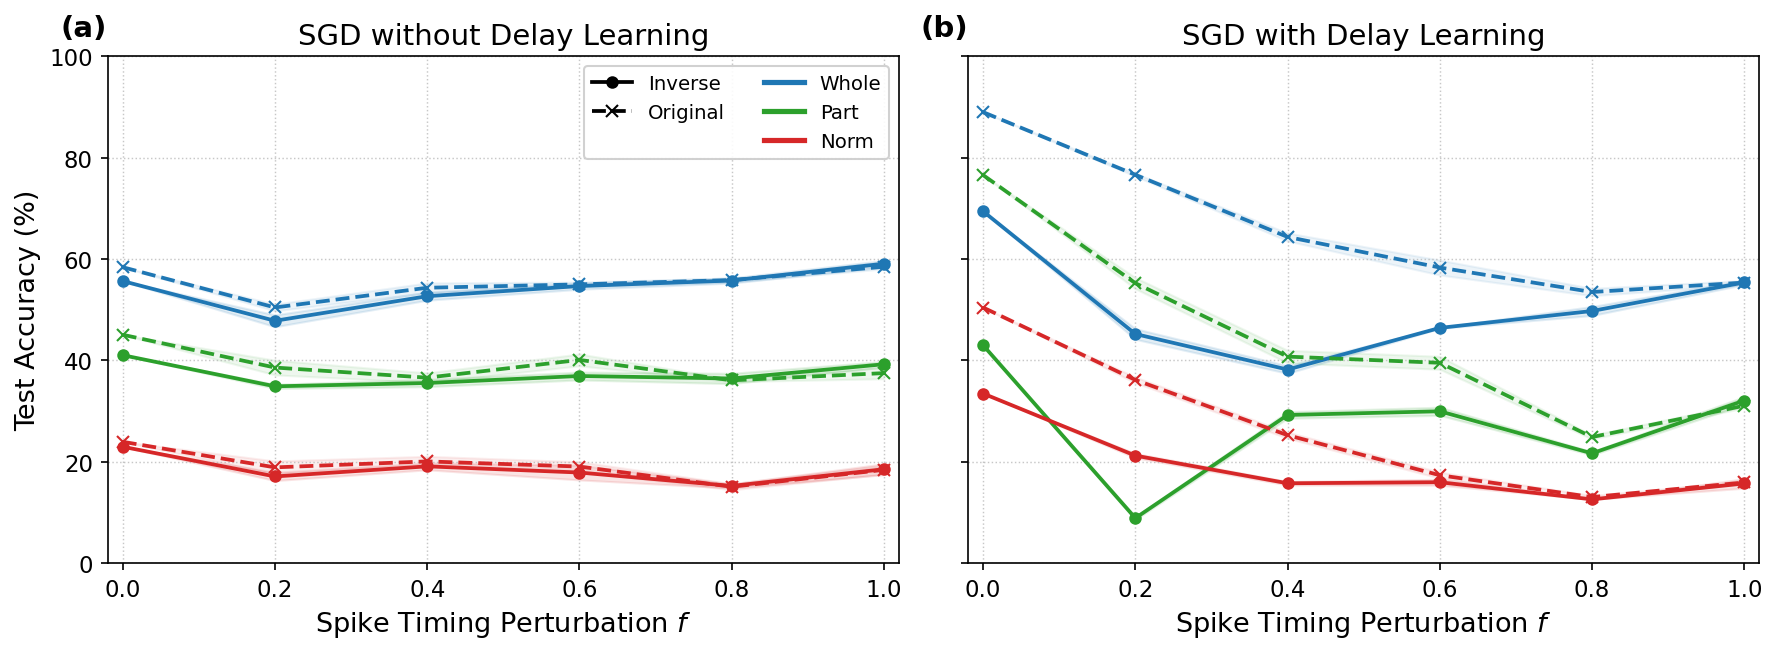

In [30]:
INVERSE_LOG = CODE_PERTURBATION_DIR / "inverse/log"

INVERSE_FILES = {
    ("Whole", True):  INVERSE_LOG / "shd_whole_delay_hidden1_reversal_sweep_results.json",
    ("Whole", False): INVERSE_LOG / "shd_whole_nodelay_hidden1_reversal_sweep_results.json",
    ("Part",  True):  INVERSE_LOG / "shd_part_delay_hidden1_reversal_sweep_results.json",
    ("Part",  False): INVERSE_LOG / "shd_part_nodelay_hidden1_reversal_sweep_results.json",
    ("Norm",  True):  INVERSE_LOG / "shd_norm_delay_hidden1_reversal_sweep_results.json",
    ("Norm",  False): INVERSE_LOG / "shd_norm_nodelay_hidden1_reversal_sweep_results.json",
}


def load_reversal_sweep(
    path: pathlib.Path, condition: str,
) -> tuple[list[float], np.ndarray, np.ndarray]:
    """Load one condition ('no_reversal' or 'reversal') from an inverse JSON."""
    with open(path) as fh:
        raw = json.load(fh)
    cond = raw[condition]
    items = sorted(((float(k), k) for k in cond), key=lambda p: p[0])
    xs = [p[0] for p in items]
    means = np.array([cond[k]["mean"] for _, k in items]) * 100
    stds  = np.array([cond[k]["std"]  for _, k in items]) * 100
    return xs, means, stds


# ---------- Plot: split by delay mode; overlay Inverse vs Original ----------
# Style matches the Beyond Rate paper figure (panel (b)/(c)):
#   Inverse  (== reversal,    solid line + filled circle marker)
#   Original (== no_reversal, dashed line + 'x' marker)
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)

for ax, panel_label, use_delay, panel_title in zip(
    axes,
    "ab",
    [False, True],
    ["SGD without Delay Learning", "SGD with Delay Learning"],
):
    for key in VARIANTS:
        path = INVERSE_FILES[(key, use_delay)]

        # Inverse (reversal) — solid line, filled circle marker
        xs, m, std = load_reversal_sweep(path, "reversal")
        ax.plot(xs, m, "o-", color=COLORS[key], markersize=5, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.12)

        # Original (no_reversal) — dashed line, 'x' marker
        xs, m, std = load_reversal_sweep(path, "no_reversal")
        ax.plot(xs, m, "x--", color=COLORS[key], markersize=6, linewidth=1.8)
        ax.fill_between(xs, m - std, m + std, color=COLORS[key], alpha=0.08)

    ax.set_title(panel_title)
    ax.set_xlabel(r"Spike Timing Perturbation $f$")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(0, 100)
    ax.grid(True, linestyle=":", linewidth=0.7, alpha=0.7)
    ax.text(-0.06, 1.04, f"({panel_label})", transform=ax.transAxes,
            fontsize=14, fontweight="bold")

axes[0].set_ylabel("Test Accuracy (%)")

# ---------- Shared legend, drawn once in the left panel ----------
# The blank third entry keeps the line styles in column 1 and the dataset
# variants together in column 2 (matplotlib fills columns top-to-bottom).
blank = mlines.Line2D([], [], linestyle="none", marker="none", label="")
handles = [
    mlines.Line2D([], [], color="black", marker="o", linestyle="-",
                  markersize=5, linewidth=1.8, label="Inverse"),
    mlines.Line2D([], [], color="black", marker="x", linestyle="--",
                  markersize=6, linewidth=1.8, label="Original"),
    blank,
] + [
    mlines.Line2D([], [], color=COLORS[variant], linewidth=2.5, label=variant)
    for variant in VARIANTS
]
axes[0].legend(handles=handles, loc="upper right", framealpha=0.9, ncol=2)

fig.tight_layout()
#plt.savefig("inverse_reversal_results.png", dpi=150, bbox_inches="tight")
plt.show()